### POC ML for Futures Trading


In [1]:
import os
import requests
import pandas as pd

# Get API key from environment variable
ALPHA_VANTAGE_API_KEY = os.environ.get("VANTAGE_API")

# If not found in environment, you can set it directly here (uncomment and replace):
# ALPHA_VANTAGE_API_KEY = "YOUR_API_KEY_HERE"

if not ALPHA_VANTAGE_API_KEY:
    print("⚠️ VANTAGE_API environment variable not found!")
    print("Either:")
    print("  1. Set it in your system environment variables and restart VS Code/Kernel")
    print("  2. Uncomment line 8 above and paste your API key directly")
else:
    print(f"✅ API Key loaded successfully (ends with: ...{ALPHA_VANTAGE_API_KEY[-4:]})")

⚠️ VANTAGE_API environment variable not found!
Either:
  1. Set it in your system environment variables and restart VS Code/Kernel
  2. Uncomment line 8 above and paste your API key directly


In [2]:
ALPHA_VANTAGE_API_KEY = "OYKYCMZRVHUB1NYZ"

In [3]:
import time

def get_stock_data(symbol, function="TIME_SERIES_DAILY", outputsize="compact"):
    """
    Fetch stock data from Alpha Vantage API.
    
    Parameters:
    - symbol: Stock ticker (e.g., "AAPL", "MSFT", "SPY")
    - function: API function (TIME_SERIES_DAILY, TIME_SERIES_INTRADAY, etc.)
    - outputsize: "compact" (last 100 data points) or "full" (full history ~20 years)
    
    Returns:
    - DataFrame with OHLCV data
    """
    base_url = "https://www.alphavantage.co/query"
    params = {
        "function": function,
        "symbol": symbol,
        "apikey": ALPHA_VANTAGE_API_KEY,
        "outputsize": outputsize,
        "datatype": "json"
    }
    
    response = requests.get(base_url, params=params)
    data = response.json()
    
    # Check for errors
    if "Error Message" in data:
        raise ValueError(f"API Error: {data['Error Message']}")
    
    # Check for rate limit or info messages
    if "Information" in data:
        print(f"⚠️ API Information: {data['Information']}")
        print("Free tier is limited to 25 requests per day. Please wait or try again tomorrow.")
        raise ValueError("API rate limit reached")
    
    if "Note" in data:
        print(f"⚠️ API Note: {data['Note']}")
    
    # Parse the time series data
    time_series_key = [key for key in data.keys() if "Time Series" in key]
    if not time_series_key:
        raise ValueError(f"Unexpected response format: {list(data.keys())}")
    
    time_series = data[time_series_key[0]]
    
    # Convert to DataFrame
    df = pd.DataFrame.from_dict(time_series, orient="index")
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    
    # Rename columns to standard OHLCV format
    df.columns = [col.split(". ")[1] if ". " in col else col for col in df.columns]
    df = df.rename(columns={
        "open": "Open",
        "high": "High", 
        "low": "Low",
        "close": "Close",
        "volume": "Volume"
    })
    
    # Convert to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df

# Download example data for Apple (AAPL)
symbol = "AAPL"
data = get_stock_data(symbol)
print(f"Downloaded {len(data)} data points for {symbol}")
print(data.tail())

Downloaded 100 data points for AAPL
              Open     High     Low   Close    Volume
2026-01-22  249.20  251.000  248.15  248.35  39708340
2026-01-23  247.32  249.410  244.68  248.04  41688982
2026-01-26  251.48  256.560  249.80  255.41  55969234
2026-01-27  259.17  261.950  258.21  258.27  48787855
2026-01-28  257.65  258.855  254.51  256.44  41287971


In [14]:
# Note: Alpha Vantage FREE tier only provides 100 data points with "compact" 
# The "full" outputsize is a PREMIUM feature.
# 
# For more historical data with free API, you have these options:
# 1. Use a different free data source (like FRED, Yahoo Finance alternatives)
# 2. Upgrade to Alpha Vantage premium
# 3. Combine multiple API endpoints (e.g., weekly + daily data)
#
# For now, we'll work with the 100 days from compact and impute missing dates

es_futures = data.copy()  # Use the data we already downloaded
print(f"Using {symbol} data with {len(es_futures)} trading days")
print(f"Date range: {es_futures.index.min()} to {es_futures.index.max()}")

Using AAPL data with 100 trading days
Date range: 2025-09-05 00:00:00 to 2026-01-28 00:00:00


In [15]:
# ============================================================================
# DATE IMPUTATION - Fill gaps for weekends and holidays
# ============================================================================

def impute_missing_dates(df, method='ffill'):
    """
    Fill gaps in time series data (weekends, holidays).
    
    Methods:
    - 'ffill': Forward fill (carry last known value forward)
    - 'linear': Linear interpolation between known values
    - 'hybrid': Forward fill for OHLC, linear for Volume
    
    Parameters:
    - df: DataFrame with DatetimeIndex
    - method: Imputation method
    
    Returns:
    - DataFrame with continuous daily dates
    """
    # Create continuous date range
    date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    
    # Reindex to include all dates
    df_continuous = df.reindex(date_range)
    
    # Count missing dates
    missing_count = df_continuous.isnull().any(axis=1).sum()
    
    if method == 'ffill':
        # Forward fill all columns
        df_filled = df_continuous.ffill()
    elif method == 'linear':
        # Linear interpolation
        df_filled = df_continuous.interpolate(method='linear')
    elif method == 'hybrid':
        # Forward fill for OHLC (prices don't change on closed days)
        # Linear interpolation for Volume
        df_filled = df_continuous.copy()
        price_cols = ['Open', 'High', 'Low', 'Close']
        for col in price_cols:
            if col in df_filled.columns:
                df_filled[col] = df_filled[col].ffill()
        if 'Volume' in df_filled.columns:
            df_filled['Volume'] = df_filled['Volume'].interpolate(method='linear')
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Handle any remaining NaN at the start (backward fill)
    df_filled = df_filled.bfill()
    
    return df_filled, missing_count

print("=" * 60)
print("DATE IMPUTATION")
print("=" * 60)

print(f"\n📅 Original data:")
print(f"   Start: {es_futures.index.min()}")
print(f"   End: {es_futures.index.max()}")
print(f"   Trading days: {len(es_futures)}")

# Calculate expected calendar days
expected_days = (es_futures.index.max() - es_futures.index.min()).days + 1
print(f"   Calendar days in range: {expected_days}")
print(f"   Missing days (weekends/holidays): {expected_days - len(es_futures)}")

# Apply imputation - using 'ffill' as it's most appropriate for stock data
# (prices don't change on non-trading days)
es_futures, missing_filled = impute_missing_dates(es_futures, method='ffill')

print(f"\n✅ After imputation:")
print(f"   Total rows: {len(es_futures)}")
print(f"   Days imputed: {missing_filled}")
print(f"   Any remaining NaN: {es_futures.isnull().sum().sum()}")

# Show sample of imputed dates (weekends)
print("\n📋 Sample showing imputed weekend dates:")
sample_start = es_futures.index.min() + pd.Timedelta(days=5)
sample_end = sample_start + pd.Timedelta(days=9)
print(es_futures.loc[sample_start:sample_end][['Open', 'High', 'Low', 'Close', 'Volume']])

DATE IMPUTATION

📅 Original data:
   Start: 2025-09-05 00:00:00
   End: 2026-01-28 00:00:00
   Trading days: 100
   Calendar days in range: 146
   Missing days (weekends/holidays): 46

✅ After imputation:
   Total rows: 146
   Days imputed: 46
   Any remaining NaN: 0

📋 Sample showing imputed weekend dates:
               Open    High       Low   Close       Volume
2025-09-10  232.185  232.42  225.9500  226.79   83440810.0
2025-09-11  226.875  230.45  226.6500  230.03   50208578.0
2025-09-12  229.220  234.51  229.0200  234.07   55824216.0
2025-09-13  229.220  234.51  229.0200  234.07   55824216.0
2025-09-14  229.220  234.51  229.0200  234.07   55824216.0
2025-09-15  237.000  238.19  235.0300  236.70   42699524.0
2025-09-16  237.175  241.22  236.3235  238.15   63421099.0
2025-09-17  238.970  240.10  237.7301  238.99   46508017.0
2025-09-18  239.970  241.20  236.6500  237.88   44249576.0
2025-09-19  241.225  246.30  240.2106  245.50  163741314.0


In [8]:
# Display raw data from Alpha Vantage
es_futures

,Open,High,Low,Close,Volume
2025-09-05,239.995,241.3200,238.4901,239.69,54870397
2025-09-08,239.300,240.1500,236.3400,237.88,48999495
2025-09-09,237.000,238.7805,233.3600,234.35,66313918
2025-09-10,232.185,232.4200,225.9500,226.79,83440810
2025-09-11,226.875,230.4500,226.6500,230.03,50208578
...,...,...,...,...,...
2026-01-22,249.200,251.0000,248.1500,248.35,39708340
2026-01-23,247.320,249.4100,244.6800,248.04,41688982
2026-01-26,251.480,256.5600,249.8000,255.41,55969234
2026-01-27,259.170,261.9500,258.2100,258.27,48787855


In [9]:
# Data is already clean from Alpha Vantage - verify structure
print("Cleaned es_futures DataFrame:")
print(f"Shape: {es_futures.shape}")
print(f"Index type: {type(es_futures.index)}")
print(f"Columns: {list(es_futures.columns)}")

# Filter to date range similar to original (from 2020 onwards)
es_futures = es_futures[es_futures.index >= "2020-01-01"]

print(f"\nFiltered to data from 2020 onwards: {len(es_futures)} rows")
print("\nFirst few rows:")
print(es_futures.head())

print("\nLast few rows:")
print(es_futures.tail())

print("\nData info:")
print(es_futures.info())

Cleaned es_futures DataFrame:
Shape: (100, 5)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Filtered to data from 2020 onwards: 100 rows

First few rows:
               Open      High       Low   Close    Volume
2025-09-05  239.995  241.3200  238.4901  239.69  54870397
2025-09-08  239.300  240.1500  236.3400  237.88  48999495
2025-09-09  237.000  238.7805  233.3600  234.35  66313918
2025-09-10  232.185  232.4200  225.9500  226.79  83440810
2025-09-11  226.875  230.4500  226.6500  230.03  50208578

Last few rows:
              Open     High     Low   Close    Volume
2026-01-22  249.20  251.000  248.15  248.35  39708340
2026-01-23  247.32  249.410  244.68  248.04  41688982
2026-01-26  251.48  256.560  249.80  255.41  55969234
2026-01-27  259.17  261.950  258.21  258.27  48787855
2026-01-28  257.65  258.855  254.51  256.44  41287971

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100 entries, 2025-09

In [10]:
# Display cleaned DataFrame
es_futures

,Open,High,Low,Close,Volume
2025-09-05,239.995,241.3200,238.4901,239.69,54870397
2025-09-08,239.300,240.1500,236.3400,237.88,48999495
2025-09-09,237.000,238.7805,233.3600,234.35,66313918
2025-09-10,232.185,232.4200,225.9500,226.79,83440810
2025-09-11,226.875,230.4500,226.6500,230.03,50208578
...,...,...,...,...,...
2026-01-22,249.200,251.0000,248.1500,248.35,39708340
2026-01-23,247.320,249.4100,244.6800,248.04,41688982
2026-01-26,251.480,256.5600,249.8000,255.41,55969234
2026-01-27,259.170,261.9500,258.2100,258.27,48787855


# Feature Engineering

- Creation of common metrics for time-series
- RSI, MACD, Bollinger Mavg, ATR, Stochastic-K, Return 1, Return 5, Rolling Average 30, 60, 90, 120, Volatility

In [16]:
# Calculate standard deviation of OHLC values for each row
import numpy as np

# Create a copy and calculate OHLC standard deviation
df_with_std = es_futures.copy()
df_with_std['OHLC_Std'] = df_with_std[['Open', 'High', 'Low', 'Close']].std(axis=1)

print("DataFrame with OHLC Standard Deviation:")
print(f"Shape: {df_with_std.shape}")
print("\nFirst few rows with new column:")
print(df_with_std[['Open', 'High', 'Low', 'Close', 'OHLC_Std']].head(10))
print("\nStatistics for OHLC_Std:")
print(df_with_std['OHLC_Std'].describe())

DataFrame with OHLC Standard Deviation:
Shape: (146, 6)

First few rows with new column:
               Open      High       Low   Close  OHLC_Std
2025-09-05  239.995  241.3200  238.4901  239.69  1.162554
2025-09-06  239.995  241.3200  238.4901  239.69  1.162554
2025-09-07  239.995  241.3200  238.4901  239.69  1.162554
2025-09-08  239.300  240.1500  236.3400  237.88  1.671853
2025-09-09  237.000  238.7805  233.3600  234.35  2.473754
2025-09-10  232.185  232.4200  225.9500  226.79  3.443592
2025-09-11  226.875  230.4500  226.6500  230.03  2.017136
2025-09-12  229.220  234.5100  229.0200  234.07  2.991415
2025-09-13  229.220  234.5100  229.0200  234.07  2.991415
2025-09-14  229.220  234.5100  229.0200  234.07  2.991415

Statistics for OHLC_Std:
count    146.000000
mean       2.292736
std        1.103331
min        0.710556
25%        1.596330
50%        2.018831
75%        2.723484
max        6.413368
Name: OHLC_Std, dtype: float64


In [17]:
# ============================================================================
# TECHNICAL INDICATORS & FEATURES
# ============================================================================

# --- RSI (Relative Strength Index) ---
def calculate_rsi(prices, period=14):
    """Calculate RSI indicator"""
    delta = prices.diff()
    gain = delta.where(delta > 0, 0)
    loss = (-delta).where(delta < 0, 0)
    
    avg_gain = gain.rolling(window=period, min_periods=1).mean()
    avg_loss = loss.rolling(window=period, min_periods=1).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df_with_std['RSI'] = calculate_rsi(df_with_std['Close'])

# --- MACD (Moving Average Convergence Divergence) ---
def calculate_macd(prices, fast=12, slow=26, signal=9):
    """Calculate MACD, Signal line, and Histogram"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

df_with_std['MACD'], df_with_std['MACD_Signal'], df_with_std['MACD_Hist'] = calculate_macd(df_with_std['Close'])

# --- Bollinger Bands ---
def calculate_bollinger_bands(prices, period=20, std_dev=2):
    """Calculate Bollinger Bands (Middle, Upper, Lower)"""
    middle = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper = middle + (std * std_dev)
    lower = middle - (std * std_dev)
    return middle, upper, lower

df_with_std['BB_Middle'], df_with_std['BB_Upper'], df_with_std['BB_Lower'] = calculate_bollinger_bands(df_with_std['Close'])

# --- ATR (Average True Range) ---
def calculate_atr(high, low, close, period=14):
    """Calculate Average True Range"""
    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = true_range.rolling(window=period).mean()
    return atr

df_with_std['ATR'] = calculate_atr(df_with_std['High'], df_with_std['Low'], df_with_std['Close'])

# --- Stochastic Oscillator (K) ---
def calculate_stochastic_k(high, low, close, period=14):
    """Calculate Stochastic %K"""
    lowest_low = low.rolling(window=period).min()
    highest_high = high.rolling(window=period).max()
    stoch_k = 100 * (close - lowest_low) / (highest_high - lowest_low)
    return stoch_k

df_with_std['Stochastic_K'] = calculate_stochastic_k(df_with_std['High'], df_with_std['Low'], df_with_std['Close'])

# --- Returns ---
df_with_std['Return_1'] = df_with_std['Close'].pct_change(1) * 100  # 1-day return in %
df_with_std['Return_5'] = df_with_std['Close'].pct_change(5) * 100  # 5-day return in %

# --- Rolling Averages (SMA) ---
df_with_std['SMA_30'] = df_with_std['Close'].rolling(window=30).mean()
df_with_std['SMA_60'] = df_with_std['Close'].rolling(window=60).mean()
df_with_std['SMA_90'] = df_with_std['Close'].rolling(window=90).mean()
df_with_std['SMA_120'] = df_with_std['Close'].rolling(window=120).mean()

# --- Volatility (Rolling Standard Deviation of Returns) ---
df_with_std['Volatility_20'] = df_with_std['Return_1'].rolling(window=20).std()  # 20-day volatility

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"\nDataFrame shape: {df_with_std.shape}")
print(f"\nNew columns added:")
new_cols = ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 
            'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'SMA_90', 
            'SMA_120', 'Volatility_20']
for col in new_cols:
    print(f"  - {col}")

print(f"\nTotal features: {len(df_with_std.columns)}")

FEATURE ENGINEERING COMPLETE

DataFrame shape: (146, 22)

New columns added:
  - RSI
  - MACD
  - MACD_Signal
  - MACD_Hist
  - BB_Middle
  - BB_Upper
  - BB_Lower
  - ATR
  - Stochastic_K
  - Return_1
  - Return_5
  - SMA_30
  - SMA_60
  - SMA_90
  - SMA_120
  - Volatility_20

Total features: 22


In [14]:
# Display sample of all features
print("Sample of engineered features (last 10 rows):\n")
display_cols = ['Close', 'OHLC_Std', 'RSI', 'MACD', 'ATR', 'Stochastic_K', 'Return_1', 'SMA_30', 'Volatility_20']
print(df_with_std[display_cols].tail(10).round(2))

print("\n" + "=" * 60)
print("FEATURE STATISTICS")
print("=" * 60)
print(df_with_std[['RSI', 'MACD', 'ATR', 'Stochastic_K', 'Return_1', 'Volatility_20']].describe().round(2))

Sample of engineered features (last 10 rows):

             Close  OHLC_Std    RSI  MACD   ATR  Stochastic_K  Return_1  \
2026-01-14  259.96      2.11  19.06 -3.75  4.05         19.24     -0.42   
2026-01-15  258.21      1.92  11.65 -3.93  4.10         11.34     -0.67   
2026-01-16  255.53      1.89  10.48 -4.24  4.20          2.62     -1.04   
2026-01-20  246.70      5.27   6.47 -5.15  4.93          9.53     -3.46   
2026-01-21  247.65      2.64   9.44 -5.72  5.25         12.29      0.39   
2026-01-22  248.35      1.30  11.87 -6.04  5.35         14.32      0.28   
2026-01-23  248.04      1.99  12.08 -6.26  5.06         16.45     -0.12   
2026-01-26  255.41      3.20  32.53 -5.76  5.29         49.69      2.97   
2026-01-27  258.27      1.76  43.58 -5.08  5.36         73.30      1.12   
2026-01-28  256.44      1.85  43.86 -4.64  5.40         70.26     -0.71   

            SMA_30  Volatility_20  
2026-01-14  271.88           0.67  
2026-01-15  270.94           0.66  
2026-01-16  269.99 

# Data Analysis

In [18]:
# ============================================================================
# DATA CLEANING
# ============================================================================

# Create a clean copy for analysis
df_clean = df_with_std.copy()

print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

# 1. Check for missing values before cleaning
print("\n📊 Missing values BEFORE cleaning:")
missing_before = df_clean.isnull().sum()
print(missing_before[missing_before > 0])
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")
print(f"Rows with any NaN: {df_clean.isnull().any(axis=1).sum()} out of {len(df_clean)}")

# 2. Remove features that require more data than we have available
# (SMA_90 needs 90 days, SMA_120 needs 120 days - we only have 100 data points)
cols_to_drop = ['SMA_90', 'SMA_120']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])
print(f"\n🗑️ Dropped columns with insufficient data: {cols_to_drop}")

# 3. Drop rows with NaN (initial rows where rolling calculations couldn't be computed)
rows_before = len(df_clean)
df_clean = df_clean.dropna()
rows_dropped = rows_before - len(df_clean)

print(f"\n✅ After dropping NaN rows:")
print(f"   Rows dropped: {rows_dropped}")
print(f"   Remaining rows: {len(df_clean)}")
print(f"   Remaining missing values: {df_clean.isnull().sum().sum()}")

# 4. Check for infinite values
inf_count = np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum()
print(f"\n♾️ Infinite values found: {inf_count}")

if inf_count > 0:
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()
    print(f"   After removing infinites: {len(df_clean)} rows")

# 5. Check for duplicates
duplicates = df_clean.index.duplicated().sum()
print(f"\n🔄 Duplicate indices: {duplicates}")

if duplicates > 0:
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    print(f"   After removing duplicates: {len(df_clean)} rows")

# 6. Summary
print("\n" + "=" * 60)
print("📈 CLEAN DATA SUMMARY")
print("=" * 60)
print(f"   Date range: {df_clean.index.min()} to {df_clean.index.max()}")
print(f"   Total rows: {len(df_clean)}")
print(f"   Total features: {len(df_clean.columns)}")
print(f"\n   Columns: {list(df_clean.columns)}")

DATA CLEANING REPORT

📊 Missing values BEFORE cleaning:
RSI                3
BB_Middle         19
BB_Upper          19
BB_Lower          19
ATR               13
Stochastic_K      13
Return_1           1
Return_5           5
SMA_30            29
SMA_60            59
SMA_90            89
SMA_120          119
Volatility_20     20
dtype: int64

Total missing values: 408
Rows with any NaN: 119 out of 146

🗑️ Dropped columns with insufficient data: ['SMA_90', 'SMA_120']

✅ After dropping NaN rows:
   Rows dropped: 59
   Remaining rows: 87
   Remaining missing values: 0

♾️ Infinite values found: 0

🔄 Duplicate indices: 0

📈 CLEAN DATA SUMMARY
   Date range: 2025-11-03 00:00:00 to 2026-01-28 00:00:00
   Total rows: 87
   Total features: 20

   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'Volatility_20']


In [8]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

# Select numeric columns for correlation (exclude Volume for cleaner viz)
feature_cols = [col for col in df_clean.columns if col not in ['Volume']]

# Calculate correlation matrix
corr_matrix = df_clean[feature_cols].corr()

# Display correlation with Close price (our target for prediction)
print("\n🎯 Correlation with Close price:")
close_corr = corr_matrix['Close'].sort_values(ascending=False)
print(close_corr.round(3))

# Display correlation with Return_1 (often used as target for prediction)
print("\n🎯 Correlation with 1-day Return:")
return_corr = corr_matrix['Return_1'].sort_values(ascending=False)
print(return_corr.round(3))

CORRELATION ANALYSIS

🎯 Correlation with Close price:
Close            1.000
Low              0.989
High             0.985
Open             0.975
MACD             0.965
MACD_Signal      0.940
RSI              0.837
BB_Middle        0.786
BB_Lower         0.760
BB_Upper         0.679
MACD_Hist        0.638
Stochastic_K     0.602
SMA_30           0.524
Return_5         0.520
ATR              0.242
Volatility_20    0.147
Return_1         0.146
OHLC_Std        -0.168
SMA_60          -0.804
Name: Close, dtype: float64

🎯 Correlation with 1-day Return:
Return_1         1.000
Stochastic_K     0.464
Return_5         0.389
RSI              0.251
Volatility_20    0.249
ATR              0.206
MACD_Hist        0.181
Close            0.146
Low              0.077
High             0.030
MACD             0.009
MACD_Signal     -0.033
Open            -0.045
BB_Upper        -0.100
BB_Middle       -0.141
BB_Lower        -0.145
SMA_60          -0.179
SMA_30          -0.259
OHLC_Std        -0.291
Name: Retu

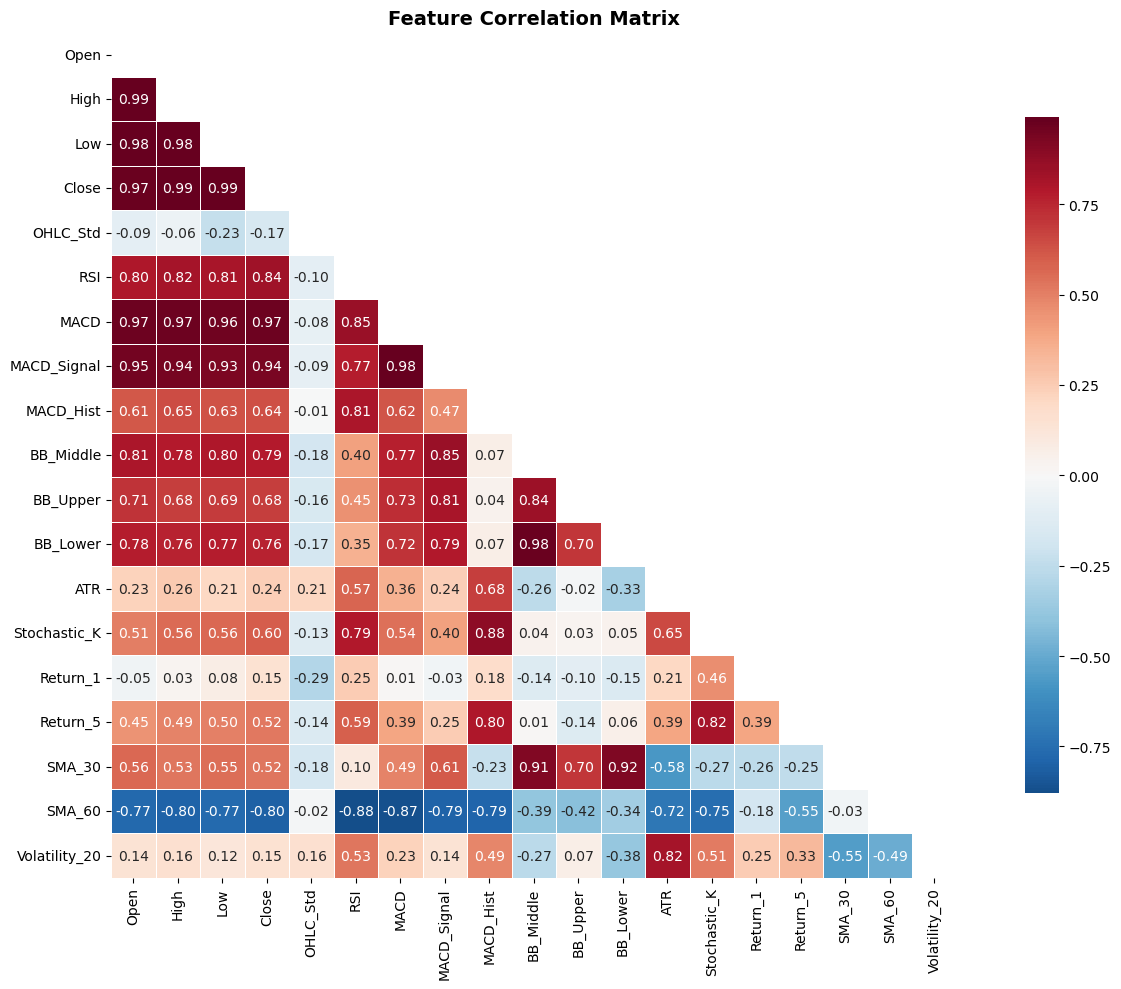


⚠️ Highly correlated feature pairs (|r| > 0.8):
   Feature 1     Feature 2  Correlation
        Open          High        0.992
         Low         Close        0.989
        High         Close        0.985
        High           Low        0.984
        Open           Low        0.983
        MACD   MACD_Signal        0.983
   BB_Middle      BB_Lower        0.976
        Open         Close        0.975
        Open          MACD        0.969
        High          MACD        0.968
       Close          MACD        0.965
         Low          MACD        0.957
        Open   MACD_Signal        0.950
        High   MACD_Signal        0.941
       Close   MACD_Signal        0.940
         Low   MACD_Signal        0.932
    BB_Lower        SMA_30        0.919
   BB_Middle        SMA_30        0.915
   MACD_Hist  Stochastic_K        0.884
         RSI          MACD        0.852
 MACD_Signal     BB_Middle        0.851
   BB_Middle      BB_Upper        0.841
       Close           RSI     

In [9]:
# Correlation Heatmap Visualization
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated features (potential multicollinearity)
print("\n⚠️ Highly correlated feature pairs (|r| > 0.8):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("   No highly correlated pairs found.")

In [19]:
# ============================================================================
# REMOVE HIGHLY CORRELATED FEATURES (|r| > 0.65)
# ============================================================================

def remove_correlated_features(df, threshold=0.65):
    """
    Remove highly correlated features, keeping one from each correlated pair.
    Uses a greedy approach: for each pair, removes the feature that has 
    higher average correlation with other features.
    """
    # Calculate correlation matrix (absolute values)
    corr_matrix = df.corr().abs()
    
    # Get upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features to drop
    to_drop = set()
    
    for col in upper.columns:
        # Find correlated features for this column
        correlated = upper.index[upper[col] > threshold].tolist()
        
        for corr_col in correlated:
            if col not in to_drop and corr_col not in to_drop:
                # Keep the feature with lower average correlation to others
                col_avg_corr = corr_matrix[col].mean()
                corr_col_avg_corr = corr_matrix[corr_col].mean()
                
                if col_avg_corr > corr_col_avg_corr:
                    to_drop.add(col)
                else:
                    to_drop.add(corr_col)
    
    return list(to_drop)

# Apply to our clean dataframe
print("=" * 60)
print("REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)")
print("=" * 60)

print(f"\nColumns BEFORE removal: {len(df_clean.columns)}")
print(f"   {list(df_clean.columns)}")

# Get features to drop (exclude Volume as it's a different type of feature)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cols_to_remove = remove_correlated_features(df_clean[numeric_cols], threshold=0.65)

print(f"\n🗑️ Columns to remove (|r| > 0.65):")
for col in sorted(cols_to_remove):
    print(f"   - {col}")

# Create reduced dataframe
df_reduced = df_clean.drop(columns=cols_to_remove)

print(f"\n✅ Columns AFTER removal: {len(df_reduced.columns)}")
print(f"   {list(df_reduced.columns)}")

# Show new correlation matrix
print("\n" + "=" * 60)
print("UPDATED CORRELATION MATRIX (remaining features)")
print("=" * 60)
reduced_corr = df_reduced.select_dtypes(include=[np.number]).corr()
print(reduced_corr.round(2))

REMOVING HIGHLY CORRELATED FEATURES (threshold = 0.65)

Columns BEFORE removal: 20
   ['Open', 'High', 'Low', 'Close', 'Volume', 'OHLC_Std', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'ATR', 'Stochastic_K', 'Return_1', 'Return_5', 'SMA_30', 'SMA_60', 'Volatility_20']

🗑️ Columns to remove (|r| > 0.65):
   - BB_Middle
   - Close
   - High
   - Low
   - MACD
   - MACD_Hist
   - MACD_Signal
   - Open
   - RSI
   - SMA_30
   - SMA_60
   - Stochastic_K

✅ Columns AFTER removal: 8
   ['Volume', 'OHLC_Std', 'BB_Upper', 'BB_Lower', 'ATR', 'Return_1', 'Return_5', 'Volatility_20']

UPDATED CORRELATION MATRIX (remaining features)
               Volume  OHLC_Std  BB_Upper  BB_Lower   ATR  Return_1  Return_5  \
Volume           1.00      0.28      0.05     -0.10  0.04     -0.00     -0.13   
OHLC_Std         0.28      1.00     -0.28     -0.07  0.33     -0.06     -0.06   
BB_Upper         0.05     -0.28      1.00      0.63 -0.37     -0.13     -0.11   
BB_Lower    

In [20]:
# Add back 'Close' as it's typically the target variable for prediction
# (Even though it's correlated with other OHLC data, we need it as target)
if 'Close' not in df_reduced.columns:
    df_reduced['Close'] = df_clean['Close']
    print("✅ Added 'Close' back as target variable")

print(f"\n📊 Final dataset for modeling:")
print(f"   Shape: {df_reduced.shape}")
print(f"   Features: {[col for col in df_reduced.columns if col != 'Close']}")
print(f"   Target: Close")

# Display final dataset
print("\n" + "=" * 60)
print("FINAL REDUCED DATASET (first 10 rows)")
print("=" * 60)
print(df_reduced.head(10).round(3))

✅ Added 'Close' back as target variable

📊 Final dataset for modeling:
   Shape: (87, 9)
   Features: ['Volume', 'OHLC_Std', 'BB_Upper', 'BB_Lower', 'ATR', 'Return_1', 'Return_5', 'Volatility_20']
   Target: Close

FINAL REDUCED DATASET (first 10 rows)
                Volume  OHLC_Std  BB_Upper  BB_Lower    ATR  Return_1  \
2025-11-03  50194583.0     2.075   277.959   246.464  5.387    -0.488   
2025-11-04  49274846.0     1.741   278.130   248.363  5.416     0.368   
2025-11-05  42586288.0     2.045   277.555   251.207  5.227     0.037   
2025-11-06  51204045.0     2.598   277.325   253.185  5.434    -0.137   
2025-11-07  48227365.0     2.329   276.538   255.590  5.475    -0.482   
2025-11-08  48227365.0     2.329   275.133   258.613  5.516     0.000   
2025-11-09  48227365.0     2.329   275.175   259.194  5.556     0.000   
2025-11-10  41312412.0     2.693   275.285   259.750  5.555     0.358   
2025-11-11  46208318.0     3.345   275.613   261.102  5.893     2.160   
2025-11-12  48397

In [21]:
df_reduced

,Volume,OHLC_Std,BB_Upper,BB_Lower,ATR,Return_1,Return_5,Volatility_20,Close
2025-11-03,50194583.0,2.075466,277.959259,246.463741,5.387136,-0.488220,-0.241009,1.200321,269.05
2025-11-04,49274846.0,1.741489,278.129532,248.363468,5.416493,0.367961,-0.501105,1.199297,270.04
2025-11-05,42586288.0,2.045361,277.555107,251.206893,5.227207,0.037032,-0.085069,1.171528,270.14
2025-11-06,51204045.0,2.597529,277.324690,253.185310,5.434357,-0.136966,-0.221918,1.121985,269.77
2025-11-07,48227365.0,2.328878,276.538260,255.589740,5.475071,-0.481892,-0.702741,1.134804,268.47
...,...,...,...,...,...,...,...,...,...
2026-01-24,41688982.0,1.987366,267.917292,244.829708,4.870714,0.000000,-2.931163,0.929185,248.04
2026-01-25,41688982.0,1.987366,266.323062,244.501938,4.923571,0.000000,0.543170,0.906270,248.04
2026-01-26,55969234.0,3.195908,265.475105,244.654895,5.210714,2.971295,3.133454,1.111166,255.41
2026-01-27,48787855.0,1.755790,265.191972,244.732028,5.433571,1.119768,3.994363,1.133712,258.27


# Training

In [12]:
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_lightning import Trainer


c:\Users\batzi\anaconda3\envs\trading_brains\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Model Training

With limited data (87 rows), we'll use models that work well with small datasets:
1. **Ridge Regression** - baseline linear model with regularization
2. **Random Forest** - ensemble method, handles non-linearity
3. **XGBoost** - gradient boosting, often best for tabular data

We'll use walk-forward validation (time series split) to avoid data leakage.

In [22]:
# ============================================================================
# PREPARE DATA FOR MODELING
# ============================================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features (X) and target (y)
feature_columns = [col for col in df_reduced.columns if col != 'Close']
X = df_reduced[feature_columns].values
y = df_reduced['Close'].values

print("=" * 60)
print("DATA PREPARATION FOR MODELING")
print("=" * 60)
print(f"\nFeatures: {feature_columns}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Scale features (important for Ridge regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Time Series Split for walk-forward validation
# With 87 samples, use 5 splits
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n📊 Time Series Cross-Validation:")
print(f"   Number of splits: {n_splits}")
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"   Split {i+1}: Train size={len(train_idx)}, Test size={len(test_idx)}")

DATA PREPARATION FOR MODELING

Features: ['Volume', 'OHLC_Std', 'BB_Upper', 'BB_Lower', 'ATR', 'Return_1', 'Return_5', 'Volatility_20']
X shape: (87, 8)
y shape: (87,)

📊 Time Series Cross-Validation:
   Number of splits: 5
   Split 1: Train size=17, Test size=14
   Split 2: Train size=31, Test size=14
   Split 3: Train size=45, Test size=14
   Split 4: Train size=59, Test size=14
   Split 5: Train size=73, Test size=14


In [24]:
# ============================================================================
# TRAIN AND EVALUATE MODELS
# ============================================================================
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define models to compare
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
}

# Store results
results = {name: {'rmse': [], 'mae': [], 'r2': []} for name in models.keys()}

print("=" * 60)
print("MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION")
print("=" * 60)

for name, model in models.items():
    print(f"\n🔄 Training: {name}")
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_scaled)):
        # Split data
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name]['rmse'].append(rmse)
        results[name]['mae'].append(mae)
        results[name]['r2'].append(r2)
    
    # Print average metrics
    avg_rmse = np.mean(results[name]['rmse'])
    avg_mae = np.mean(results[name]['mae'])
    avg_r2 = np.mean(results[name]['r2'])
    
    print(f"   Avg RMSE: ${avg_rmse:.2f}")
    print(f"   Avg MAE:  ${avg_mae:.2f}")
    print(f"   Avg R²:   {avg_r2:.4f}")

# ============================================================================
# MODEL COMPARISON SUMMARY
# ============================================================================

# Create summary DataFrame
summary_data = []
for name in models.keys():
    summary_data.append({
        'Model': name,
        'Avg RMSE': np.mean(results[name]['rmse']),
        'Std RMSE': np.std(results[name]['rmse']),
        'Avg MAE': np.mean(results[name]['mae']),
        'Avg R²': np.mean(results[name]['r2'])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Avg RMSE')

print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

# Find best model
best_model_name = summary_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")

MODEL TRAINING WITH TIME SERIES CROSS-VALIDATION

🔄 Training: Ridge Regression
   Avg RMSE: $5.91
   Avg MAE:  $5.02
   Avg R²:   -3.7559

🔄 Training: Random Forest
   Avg RMSE: $7.46
   Avg MAE:  $6.58
   Avg R²:   -6.5278

🔄 Training: Gradient Boosting
   Avg RMSE: $8.29
   Avg MAE:  $7.21
   Avg R²:   -9.0315

MODEL COMPARISON SUMMARY
            Model  Avg RMSE  Std RMSE  Avg MAE    Avg R²
 Ridge Regression  5.905179  1.867272 5.022042 -3.755896
    Random Forest  7.455047  4.447020 6.580843 -6.527805
Gradient Boosting  8.286661  4.611691 7.209219 -9.031456

🏆 Best Model: Ridge Regression


FINAL MODEL EVALUATION (Ridge Regression)

📊 Holdout Set Performance (last 10 days):
   RMSE: $8.17
   MAE:  $7.62
   R²:   -2.6099


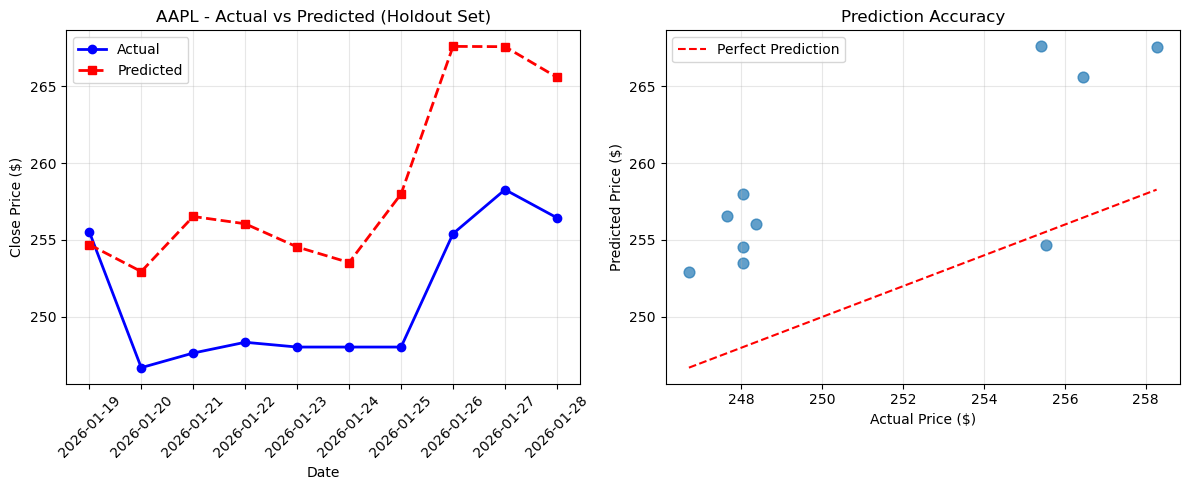

In [25]:
# ============================================================================
# FINAL MODEL - TRAIN ON ALL DATA & VISUALIZE PREDICTIONS
# ============================================================================

# Train best model on all data except last 10 days (holdout for visualization)
holdout_size = 10
X_train_final = X_scaled[:-holdout_size]
y_train_final = y[:-holdout_size]
X_holdout = X_scaled[-holdout_size:]
y_holdout = y[-holdout_size:]

# Get the best model class and retrain
best_model = models[best_model_name]
best_model.fit(X_train_final, y_train_final)

# Predict on holdout
y_pred_holdout = best_model.predict(X_holdout)

# Calculate final metrics
final_rmse = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout))
final_mae = mean_absolute_error(y_holdout, y_pred_holdout)
final_r2 = r2_score(y_holdout, y_pred_holdout)

print("=" * 60)
print(f"FINAL MODEL EVALUATION ({best_model_name})")
print("=" * 60)
print(f"\n📊 Holdout Set Performance (last {holdout_size} days):")
print(f"   RMSE: ${final_rmse:.2f}")
print(f"   MAE:  ${final_mae:.2f}")
print(f"   R²:   {final_r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

# Get dates for holdout period
holdout_dates = df_reduced.index[-holdout_size:]

plt.subplot(1, 2, 1)
plt.plot(holdout_dates, y_holdout, 'b-o', label='Actual', linewidth=2, markersize=6)
plt.plot(holdout_dates, y_pred_holdout, 'r--s', label='Predicted', linewidth=2, markersize=6)
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.title(f'{symbol} - Actual vs Predicted (Holdout Set)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_holdout, y_pred_holdout, alpha=0.7, s=60)
plt.plot([y_holdout.min(), y_holdout.max()], [y_holdout.min(), y_holdout.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Prediction Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    print("\n📈 Feature Importance:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(importance_df.to_string(index=False))